In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 租租通

In [ ]:
#租租通
import requests

url = "https://www.dd-room.com/search?category=house&city=臺北市&area=文山區&order=recommend&sort=desc&page=1"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
}

res = requests.get(url, headers=headers)

print(res.status_code)      # 應該 200
print(res.text[:2000])      # 先看前 2000 字


200
<!doctype html>
<html data-n-head-ssr lang="zh-Hant" data-n-head="%7B%22lang%22:%7B%22ssr%22:%22zh-Hant%22%7D%7D">
  <head >
    <title>臺北市文山區租屋｜租租通 最優質租屋網站</title><meta data-n-head="ssr" charset="utf-8"><meta data-n-head="ssr" name="viewport" content="width=device-width, initial-scale=1"><meta data-n-head="ssr" data-hid="ogUrl" property="og:url" content="https://www.dd-room.com/"><meta data-n-head="ssr" data-hid="ogType" property="og:type" content="website"><meta data-n-head="ssr" data-hid="ogImage" property="og:image" content="https://static.dd-room.com/images/dist/banner/dd-room.jpg"><meta data-n-head="ssr" data-hid="ogTitle" property="og:title" content="臺北市文山區租屋｜租租通 最優質租屋網站"><meta data-n-head="ssr" data-hid="description" name="description" content="正在尋找臺北市文山區的家嗎？
        租租通提供最完整的臺北市文山區租屋資訊，
        還可以依需求篩選可租補、可養寵、可開伙、台水台電...等條件。
        無論是溫馨套房、家庭公寓或整層住家，都能立即找到您的理想住宅！"><meta data-n-head="ssr" data-hid="ogDescription" property="og:description" content="正在尋找臺北市文山區的家嗎？
        租

In [ ]:
import requests
import time
import random
from bs4 import BeautifulSoup

class DDroomScraper:
    HEADERS = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0 Safari/537.36"
        )
    }

    BASE_URL = (
        "https://www.dd-room.com/search?category=house&city=臺北市&area=文山區&order=recommend&sort=desc"
    )

    def __init__(self):
        self.session = requests.Session()
        self.session.headers.update(self.HEADERS)

    def get_html(self, url):
        resp = self.session.get(url, timeout=10)
        resp.raise_for_status()
        return resp.text

    def parse_page(self, html):
        soup = BeautifulSoup(html, "html.parser")
        #print(html)
        container = soup.select_one("div.w-full.lg\\:mr-6")
        #print(container.text)
        cards = container.select("div.md\\:flex.md\\:py-6")

        print(f"找到 {len(cards)} 個物件")

        result = []
        for card in cards:
            price_tag = card.find("span", class_="text-xl font-semibold text-gray-700 md:text-2xl")
            area_tag = card.find("span", class_="area")

            price = price_tag.get_text(strip=True) if price_tag else None
            area = area_tag.get_text(strip=True) if area_tag else None
            result.append((price, area))

        return result

    def scrape(self, pages=4):
        all_data = []
        for page in range(1, pages + 1):
            url = f"{self.BASE_URL}&page={page}"
            print(f"爬第 {page} 頁")
            html = self.get_html(url)
            page_data = self.parse_page(html)
            all_data.extend(page_data)
            time.sleep(random.uniform(1, 2))  # 模擬真人
        return all_data


# ======================
# 使用範例
# ======================
if __name__ == "__main__":
    scraper = DDroomScraper()
    data = scraper.scrape(pages=4)  # 可以改抓幾頁
    print(data[:5])
    print(f"總筆數：{len(data)}")


爬第 1 頁
找到 0 個物件
爬第 2 頁
找到 0 個物件
爬第 3 頁
找到 0 個物件
爬第 4 頁
找到 0 個物件
[]
總筆數：0


# 顯示中文

In [ ]:
import requests
import zipfile
import matplotlib as mpl

url = "https://yenlung.me/NotoSansTC"
filename = "Noto_Sans_TC.zip"

response = requests.get(url, stream=True)
if response.status_code == 200:
    with open(filename, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Downloaded {filename}")
else:
    print(f"Failed to download {filename}. Status code: {response.status_code}")



filename = "Noto_Sans_TC.zip"
try:
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall(".")  # Extract to the current directory
    print(f"Extracted {filename}")
except FileNotFoundError:
    print(f"Error: {filename} not found. Please make sure the file was downloaded correctly.")
except zipfile.BadZipFile:
    print(f"Error: {filename} is not a valid zip file.")

mpl.font_manager.fontManager.addfont("static/NotoSansTC-Bold.ttf")
mpl.rc("font",family="Noto Sans TC")

Downloaded Noto_Sans_TC.zip
Extracted Noto_Sans_TC.zip


# 591

In [ ]:
#591
import time
import random
import requests
import re
from bs4 import BeautifulSoup
from urllib.parse import urlencode
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
import folium
import branca.colormap as cm
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from time import sleep


class House591Spider:
    def __init__(self):
        """初始化 session 和 headers"""
        self.session = requests.Session()
        self.headers = {
            'user-agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/129.0.0.0 Safari/537.36',
        }

    def get_house_info(self, house_url):  #回傳get_house_ids_from_page
        """根據給定的 URL 取得網頁內容並解析出房屋 ID"""
        try:
          response = self.session.get(house_url, headers=self.headers)
          response.raise_for_status()  # 如果狀態碼不是 200，則引發異常
        except requests.exceptions.RequestException as e:
          print(f"Error fetching data: {e}")
          return set()  # 返回空的 set

        soup = BeautifulSoup(response.text, 'html.parser')  #取得html
        results = self.get_house_ids_from_page(soup)  #帶入html
        return results

    def get_house_ids_from_page(self, soup):  #回傳租金，坪數
        items = soup.select('div.item')
        # print(type(items))
        # print(f"item :{items[0].prettify()}")
        rents = []
        pings = []
        tags = []
        address=[]
        types_=[]
        label_dict = {}
        titles = []
        i = 0
        for it in items:
          #租金
          rent = it.select_one(".item-info-price .inline-flex-row")
          rent = rent.get_text(" ", strip=True)
          rents.append(rent)
          #坪數
          ping = it.select_one(".item-info-flex .inline-flex-row")
          ping = ping.get_text(" ", strip=True).replace("坪", "")
          pings.append(ping)
          #地址

          elements = it.select(".item-info-flex .inline-flex-row")

          for el in elements:
            text = el.get_text(strip=True)
            if "區" in text:
              address.append(text)
          #print(address)

          #雅套房
          type_ = it.select_one(".item-info-txt")
          room_type = type_.find('span').text
          types_.append(room_type)

          #tags
          labels = it.find_all("span", class_="tag")
          tmp = []
          for label in labels:
            if label.get("class")==['tag']:  #得到tag
              key = label.get_text()

              if key not in label_dict.keys():  #存tag
                label_dict[key] = []  #將key存入dict
              label_dict[key].append(i)  #將i存入dict
              tmp.append(key)
          tags.append(tmp)
          i += 1

          #標題
          a_tag = it.select_one('a.link.v-middle')
          if a_tag:
            title = a_tag.get('title')
          if title:
            titles.append(title.strip())

        return rents, pings, tags, address, types_, titles

    def search(self, url):  #回傳get_house_info
        """搜尋房屋，根據篩選條件和排序條件"""

        # 使用 urllib.parse 組合查詢參數
        search_url = url
        print(f"Requesting: {search_url}")

        return self.get_house_info(search_url)




In [ ]:
house591_spider = House591Spider() #建立物件，賦予它class內的功能
rent_list = []
ping_list = []
tag_list = []
address_list=[]
types_list=[]
titles_list=[]
for page_id in range(1, 14):
  url = f"https://rent.591.com.tw/list?region=1&section=12&price=5000_10000,10000_20000,0_5000&&page={page_id}"
  rents, pings, tags, address , types_ , titles= house591_spider.search(url)
  rent_list += rents
  ping_list += pings
  tag_list += tags
  address_list += address
  types_list += types_
  titles_list.extend(titles)
print(types_list)

Requesting: https://rent.591.com.tw/list?region=1&section=12&price=5000_10000,10000_20000,0_5000&&page=1
Requesting: https://rent.591.com.tw/list?region=1&section=12&price=5000_10000,10000_20000,0_5000&&page=2
Requesting: https://rent.591.com.tw/list?region=1&section=12&price=5000_10000,10000_20000,0_5000&&page=3
Requesting: https://rent.591.com.tw/list?region=1&section=12&price=5000_10000,10000_20000,0_5000&&page=4
Requesting: https://rent.591.com.tw/list?region=1&section=12&price=5000_10000,10000_20000,0_5000&&page=5
Requesting: https://rent.591.com.tw/list?region=1&section=12&price=5000_10000,10000_20000,0_5000&&page=6
Requesting: https://rent.591.com.tw/list?region=1&section=12&price=5000_10000,10000_20000,0_5000&&page=7
Requesting: https://rent.591.com.tw/list?region=1&section=12&price=5000_10000,10000_20000,0_5000&&page=8
Requesting: https://rent.591.com.tw/list?region=1&section=12&price=5000_10000,10000_20000,0_5000&&page=9
Requesting: https://rent.591.com.tw/list?region=1&secti

In [ ]:
import re
df_titles = pd.DataFrame({
    'title': titles_list
})


df_titles['title_clean'] = df_titles['title'].str.replace(r'[^\u4e00-\u9fffA-Za-z0-9★☆（）()\-\s]', '', regex=True)

df_titles

,title,title_clean
0,木柵市場旁黃金二樓｜台水台電,木柵市場旁黃金二樓台水台電
1,🌿文山｜忠順街｜兩房一廳｜CP值高｜近實踐國小🌿,文山忠順街兩房一廳CP值高近實踐國小
2,✨世新🌆景美捷運景美夜市🏡電梯獨立套房👜,世新景美捷運景美夜市電梯獨立套房
3,短租❤飲水機❤免爬高❤寵物❤近政大❤傢俱全新,短租飲水機免爬高寵物近政大傢俱全新
4,萬隆景美小資族雅房.可短租.1.5押金.,萬隆景美小資族雅房可短租15押金
...,...,...
385,生活機能便利的女生小套房,生活機能便利的女生小套房
386,木新路免去河堤找車位又不安全,木新路免去河堤找車位又不安全
387,優質獨立洗衣機陽台套房,優質獨立洗衣機陽台套房
388,文山區景美女中旁轎車機械車位,文山區景美女中旁轎車機械車位


In [ ]:
#將tag換成0,1
mlb = MultiLabelBinarizer()
tags_encoded = mlb.fit_transform(tag_list)
df = pd.DataFrame(tags_encoded, columns=mlb.classes_)

#加上ping
df['ping']=ping_list
df['ping']=df['ping'].astype(float)

#加上addr
df['addr']=address_list
#清理
df['addr']=(
    '台北市'+
    df['addr']
    .str.replace('-','',regex=False)
    .str.strip()
)

#新增租金欄位
df['Rent']=rent_list
# 去除逗號並轉為數字
df['Rent'] = df['Rent'].astype(str).str.replace(',', '')
df['Rent'] = pd.to_numeric(df['Rent'], errors='coerce')

#新增房型
df['type']= types_list

#新增標題
df['title']= titles_list

#加入區域標籤
#df['區域標籤'] = df_addr['區域標籤']


#把其他、車位刪掉
df = df[(df['type'] != '其他') & (df['type'] != '車位')]

#拆type
#df = pd.get_dummies(df, columns=['type'], dtype=int)
#將欄位名稱中的 'type_' 替換成空白 (也就是刪除它)
#df.columns = df.columns.str.replace('type_', '')



#刪掉近商圈，近捷運標籤
df = df.drop(columns=['近商圈', '近捷運'])

df = df.reset_index(drop=True)

df

,拎包入住,AI影音,免服務費,免管理費,南北通透,可入籍,可報稅,可短租,可開伙,可養寵物,...,有電梯,社會住宅,租金補貼,隨時可遷入,高齡友善,ping,addr,Rent,type,title
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,7.0,台北市文山區保儀路,7500,雅房,木柵市場旁黃金二樓｜台水台電
1,1,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,20.0,台北市文山區忠順街一段48巷6號,19500,整層住家,🌿文山｜忠順街｜兩房一廳｜CP值高｜近實踐國小🌿
2,0,0,0,0,0,0,0,0,1,0,...,1,0,1,1,0,5.0,台北市文山區仙岩路16巷,16000,獨立套房,✨世新🌆景美捷運景美夜市🏡電梯獨立套房👜
3,1,0,0,0,0,0,0,1,1,1,...,0,0,0,1,0,4.0,台北市文山區指南路二段,5999,雅房,短租❤飲水機❤免爬高❤寵物❤近政大❤傢俱全新
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,3.0,台北市文山區羅斯福路六段159巷5弄,5800,雅房,萬隆景美小資族雅房.可短租.1.5押金.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,7.0,台北市文山區興隆路一段102巷,9000,雅房,萬隆捷運站近台大公館商圈優質機能包水電
356,1,0,0,0,0,0,0,0,1,1,...,0,0,0,1,0,16.0,台北市文山區景興路153巷,19500,整層住家,1+1房寵物天堂大空間使用2房
357,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,3.5,台北市文山區辛亥路五段,6000,分租套房,生活機能便利的女生小套房
358,0,0,0,0,0,0,0,0,1,1,...,0,0,0,1,0,7.0,台北市文山區保儀路,10500,獨立套房,優質獨立洗衣機陽台套房


# 地址轉經緯

In [ ]:
address = df['addr']
print(address)

0               台北市文山區保儀路
1        台北市文山區忠順街一段48巷6號
2            台北市文山區仙岩路16巷
3             台北市文山區指南路二段
4      台北市文山區羅斯福路六段159巷5弄
              ...        
355       台北市文山區興隆路一段102巷
356         台北市文山區景興路153巷
357           台北市文山區辛亥路五段
358             台北市文山區保儀路
359           台北市文山區興隆路二段
Name: addr, Length: 360, dtype: object


In [ ]:
from geopy.geocoders import ArcGIS
import pandas as pd
from tqdm import tqdm # 讓你看到進度條

# 1. 改用 ArcGIS (不需要 user_agent)
geolocator = ArcGIS()

lats = []
lngs = []

print("開始極速轉換 (使用 ArcGIS)...")

# 使用 tqdm 顯示進度條，讓你不用乾等
for addr in tqdm(df['addr']):
    try:
        # ArcGIS 對台灣地址支援不錯，通常不用加 "台北市" 也能找到，但加上去更保險
        location = geolocator.geocode("台北市" + addr, timeout=10)

        if location:
            lats.append(location.latitude)
            lngs.append(location.longitude)
        else:
            lats.append(None)
            lngs.append(None)
    except Exception as e:
        print(f"Error: {e}")
        lats.append(None)
        lngs.append(None)

df['lat'] = lats
df['lng'] = lngs

print("轉換完成！")

開始極速轉換 (使用 ArcGIS)...


100%|██████████| 360/360 [02:11<00:00,  2.74it/s]

轉換完成！


In [ ]:
df['lat'] =df['lat'].astype(float)
df['lng'] =df['lng'].astype(float)
df

,拎包入住,AI影音,免服務費,免管理費,南北通透,可入籍,可報稅,可短租,可開伙,可養寵物,...,租金補貼,隨時可遷入,高齡友善,ping,addr,Rent,type,title,lat,lng
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,7.0,台北市文山區保儀路,7500,雅房,木柵市場旁黃金二樓｜台水台電,24.986156,121.567796
1,1,0,0,0,0,0,0,0,1,0,...,0,1,0,20.0,台北市文山區忠順街一段48巷6號,19500,整層住家,🌿文山｜忠順街｜兩房一廳｜CP值高｜近實踐國小🌿,24.983400,121.560127
2,0,0,0,0,0,0,0,0,1,0,...,1,1,0,5.0,台北市文山區仙岩路16巷,16000,獨立套房,✨世新🌆景美捷運景美夜市🏡電梯獨立套房👜,24.995930,121.550419
3,1,0,0,0,0,0,0,1,1,1,...,0,1,0,4.0,台北市文山區指南路二段,5999,雅房,短租❤飲水機❤免爬高❤寵物❤近政大❤傢俱全新,24.987000,121.578479
4,0,0,0,0,0,0,0,0,1,0,...,0,1,0,3.0,台北市文山區羅斯福路六段159巷5弄,5800,雅房,萬隆景美小資族雅房.可短租.1.5押金.,24.997416,121.541453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,1,0,0,0,0,0,0,0,0,0,...,0,1,0,7.0,台北市文山區興隆路一段102巷,9000,雅房,萬隆捷運站近台大公館商圈優質機能包水電,25.002736,121.541083
356,1,0,0,0,0,0,0,0,1,1,...,0,1,0,16.0,台北市文山區景興路153巷,19500,整層住家,1+1房寵物天堂大空間使用2房,24.993756,121.545736
357,1,0,0,0,0,0,0,0,0,0,...,0,1,0,3.5,台北市文山區辛亥路五段,6000,分租套房,生活機能便利的女生小套房,24.998160,121.553072
358,0,0,0,0,0,0,0,0,1,1,...,0,1,0,7.0,台北市文山區保儀路,10500,獨立套房,優質獨立洗衣機陽台套房,24.986156,121.567796


In [ ]:
df.loc[349]

,349
拎包入住,0
AI影音,0
免服務費,0
免管理費,0
南北通透,0
可入籍,0
可報稅,0
可短租,0
可開伙,0
可養寵物,0


# 分區

In [ ]:
# --- 準備政大座標 ---
nccu_lat = 24.9876
nccu_lng = 121.5754

# --- 第三步：依照租金高低製作顏色漸層 ---

# 建立顏色對應表 (Colormap)
# vmin: 最低租金, vmax: 最高租金
# colors: ['pink', 'red', 'darkred'] 代表從 粉紅 -> 紅 -> 深紅
colormap = cm.LinearColormap(
    colors=['pink', 'red', '#8B0000'], # #8B0000 是深紅色 Hex
    vmin=df['Rent'].min(),
    vmax=df['Rent'].max(),
    caption='租金高低 (深色=貴)'
)

# --- 第四步：畫地圖 (圓點模式) ---

# 以所有點的平均位置當作地圖中心
center_lat = df['lat'].mean()
center_lng = df['lng'].mean()

m = folium.Map(location=[center_lat, center_lng], zoom_start=14, tiles="OpenStreetMap")

for idx, row in df.iterrows():
    # 取得該租金對應的顏色
    color_code = colormap(row['Rent'])

    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=6,                # 圓點大小
        color=color_code,        # 邊框顏色
        fill=True,
        fill_color=color_code,   # 填充顏色
        fill_opacity=0.7,        # 透明度
        popup=f"<b>{row['addr']}</b><br>租金: {int(row['Rent'])} 元", # 點擊顯示資訊
    ).add_to(m)

#標出政大位置
folium.Marker(
    location=[nccu_lat, nccu_lng],
    popup="<b>國立政治大學</b>",
    icon=folium.Icon(color="blue", icon="info-sign"), # 藍色圖標
    tooltip="政大在這裡"
).add_to(m)

# 把顏色圖例加到地圖上
m.add_child(colormap)



# 顯示地圖
m

In [ ]:
error_idx = X_test[abs(y_pred - y_test) > 1000].index
for idx in error_idx:
    row = df.loc[idx]

    # 找到對應的預測值
    i = X_test.index.get_loc(idx)
    pred = y_pred[i]
    real = y_test.loc[idx]
    err = abs(pred - real)

    folium.Marker(
        location=[row['lat'], row['lng']],
        popup=(
            f"<b>誤差點 (index {idx})</b><br>"
            f"{row['addr']}<br><br>"
            f"實際租金: {int(real)} 元<br>"
            f"預測租金: {int(pred)} 元<br>"
            f"誤差: {int(err)} 元"
        ),
        tooltip=f"{int(real)}元",  # 滑過去直接看到租金
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(m)

m

# kmeans

In [ ]:
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer

def tokenize(text):
    return ' '.join(jieba.cut(text))


input = df['title'].apply(tokenize)
# # 套用斷詞
# X_train['text_cut'] = X_train['text'].apply(tokenize)
# X_test['text_cut']  = X_test['text'].apply(tokenize)

# # TF-IDF
vectorizer = TfidfVectorizer(max_features=100)
result = vectorizer.fit_transform(input)
# text_test  = vectorizer.transform(X_test['text_cut'])

/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.902 seconds.
DEBUG:jieba:Loading model cost 0.902 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


In [ ]:
result

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1556 stored elements and shape (360, 100)>

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import folium

# ==========
# 1. 基本清理
# ==========
df = df.copy()

df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['lng'] = pd.to_numeric(df['lng'], errors='coerce')

df = df.dropna(subset=['lat', 'lng']).reset_index(drop=True)

# ==========
# 2. KMeans 分群
# ==========
coords = df[['lat', 'lng']].copy()

k = 20   # 你可以改成 4、5、6 試試看

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(coords)

# 群中心
centers = kmeans.cluster_centers_

print(df[['addr', 'lat', 'lng', 'cluster']].head())
print("群中心：")
print(centers)

# ==========
# 3. 畫地圖
# ==========
center_lat = df['lat'].mean()
center_lng = df['lng'].mean()

m = folium.Map(location=[center_lat, center_lng], zoom_start=14)

colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'cadetblue', 'black']

for _, row in df.iterrows():
    cluster_id = int(row['cluster'])
    color = colors[cluster_id % len(colors)]

    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=f"""
        <b>{row['addr']}</b><br>
        Cluster: {cluster_id}
        """
    ).add_to(m)

for i, center in enumerate(centers):
    folium.Marker(
        location=[center[0], center[1]],
        popup=f"Cluster Center {i}",
        icon=folium.Icon(color='black', icon='info-sign')
    ).add_to(m)

m

                 addr        lat         lng  cluster
0           台北市文山區保儀路  24.986156  121.567796       16
1    台北市文山區忠順街一段48巷6號  24.983400  121.560127        4
2        台北市文山區仙岩路16巷  24.995930  121.550419        7
3         台北市文山區指南路二段  24.987000  121.578479        9
4  台北市文山區羅斯福路六段159巷5弄  24.997416  121.541453       11
群中心：
[[ 24.98631124 121.54809512]
 [ 24.99950687 121.57042078]
 [ 25.00203272 121.54095241]
 [ 24.99964973 121.5571449 ]
 [ 24.98188319 121.55865851]
 [ 24.99394108 121.54346057]
 [ 24.99013337 121.5741559 ]
 [ 24.99847155 121.5526119 ]
 [ 24.9868487  121.56232601]
 [ 24.98698862 121.58306341]
 [ 24.99489487 121.56002037]
 [ 24.99780986 121.53794416]
 [ 25.01639588 121.53042925]
 [ 25.00004543 121.54859381]
 [ 25.0048789  121.53859075]
 [ 24.99037486 121.54076168]
 [ 24.98686836 121.56834013]
 [ 25.00786266 121.55976403]
 [ 24.99054852 121.54722782]
 [ 24.97633042 121.58769879]]


In [ ]:

df['cluster'] = df['cluster'].astype('category')
df['type'] = df['type'].astype('category')
df

print(df['cluster'].dtype)
print(df['type'].dtype)


category
category


In [ ]:

path = "/content/drive/MyDrive/租金專案"
df.to_csv(path+"/591完整資料.csv", index=False)

# 拆標題

In [ ]:
import pandas as pd
import re

def clean_title(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # 去 emoji / 奇怪符號
    text = re.sub(r'[✨🍎🚇🏠🏡🏢💖♥️❤️★☆◎●•▪▫◆◇■□※☀️🔥👉👈✅✔️✦✧⬆️⬇️📍🔹🔸⚡️⚠️🎉🉐🈵🈴]', ' ', text)

    # 去常見標點
    text = re.sub(r'[|｜/\\\-\+\(\)\[\]{}【】「」『』〈〉《》,，.。!！?？:：;；~～"“”\'‘’]', ' ', text)

    # 只保留中文、英文、數字、空白
    text = re.sub(r'[^0-9a-zA-Z\u4e00-\u9fff\s]', ' ', text)

    # 空白整理
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['title_clean'] = df['title'].apply(clean_title)

In [ ]:
import pandas as pd
import re
import jieba
from collections import Counter

# 清理文字：只去符號
def clean_title(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r'[^\u4e00-\u9fff0-9a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['title_clean'] = df['title'].apply(clean_title)

# jieba 斷詞
df['title_tokens'] = df['title_clean'].apply(jieba.lcut)


# 統計全部詞頻
all_tokens = []
for tokens in df['title_tokens']:
    all_tokens.extend(tokens)

token_count = Counter(all_tokens)
token_df = pd.DataFrame(token_count.items(), columns=['word', 'count'])
token_df = token_df.sort_values('count', ascending=False)
token_df

/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.876 seconds.
DEBUG:jieba:Loading model cost 0.876 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


,word,count
4,,892
22,套房,116
17,景美,57
141,醫院,50
162,超值,45
...,...,...
799,樓頂加,1
798,停車,1
797,機車,1
796,站牌,1


In [ ]:
df["可租補"] = df["title"].str.contains("租補|租屋補助|可租補", na=False).astype(int)
df["陽台"] = df["title"].str.contains("陽台", na=False).astype(int)


In [ ]:
df["可租補"].value_counts()

,count
可租補,
0,294
1,66


In [ ]:
type_map = {
    "雅房": 1,
    "分租套房": 2,
    "獨立套房": 3,
    "整層住家": 4
}

df["type"] = df["type"].map(type_map)

In [ ]:
df.loc[[74]]

,拎包入住,AI影音,免服務費,免管理費,南北通透,可入籍,可報稅,可短租,可開伙,可養寵物,...,Rent,type,title,lat,lng,cluster,title_clean,title_tokens,可租補,陽台
74,1,0,0,0,0,0,0,0,1,0,...,20000,2,景美愛買一樓大套房_近捷運,24.989397,121.541928,15,景美愛買一樓大套房 近捷運,"['景美', '愛買', '一樓', '大', '套房', ' ', '近捷運']",0,0


## 取完整資料

In [ ]:

path = "/content/drive/MyDrive/租金專案"
df.to_csv(path + "/591完整資料.csv", index=False)


NameError: name 'df' is not defined

In [ ]:
#連接雲端並存檔
# 1. 連接 Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import time
import random
import requests
import re
from bs4 import BeautifulSoup
from urllib.parse import urlencode
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
import folium
import branca.colormap as cm
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from time import sleep
df = pd.read_csv("/content/drive/MyDrive/租金專案/591完整資料.csv")

In [ ]:

outliers = [210,15]
df = df.drop(index=outliers)


## 分析租金與tag

租金 = 坪數*x1 + 可開火**x2 + c
  
坪數 可開火     租金
5     1(or 0)   3000

In [ ]:
#雅房
#elegant_df=df[df['type']=='雅房']
#elegant_df

In [ ]:
#獨立套房
#suite_df=df[df['type']=='獨立套房']
#suite_df

In [ ]:
feature_names = [' 拎包入住', 'AI影音',   '可短租', '可開伙',
       '可養寵物', '押一付一',  '有陽台', '有電梯',  '租金補貼',
       '高齡友善', 'ping',
        'cluster','type','可租補']

df_new=df[feature_names]

df_rent = df['Rent']


#'南北通透' ,'有車位', '免管理費', '可入籍','可報稅','社會住宅','免服務費', '新上架','隨時可遷入',

# linear加權分析

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.linear_model import LinearRegression
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_absolute_error, mean_squared_error

# X = df_new.drop(['Rent'], axis=1)
# y = df_new['Rent']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# model = LinearRegression(positive=True)
# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

# print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")

Mean Absolute Error: 1970.0553196104488


In [ ]:
# coefficients = model.coef_
# feature_names = X.columns

# print("Ridge 回歸後的參數 (係數):")
# for name, coef in zip(feature_names, coefficients):
#     print(f"{name}: {coef:.2f}")

# y_pred = model.predict(X_test)
# print(f"\nMAE: {mean_absolute_error(y_test, y_pred)}")

# xgb

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from scipy.special import expit  # sigmoid

# 建立模型
model = XGBRegressor(
    n_estimators=300,     # 樹的數量
    max_depth=6,          # 樹的最大深度
    learning_rate=0.05,   # 每棵樹對最終預測的影響
    subsample=0.8,        # 隨機取樣資料防 overfit
    colsample_bytree=0.8, # 隨機取樣 feature
    random_state=42,
    enable_categorical = True,
    objective="reg:absoluteerror"
)

X = df_new
y = df_rent
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
steepness = 0.5
X_train["ping"].mean()
w = 1 + 2 * expit((X_train["ping"] - X_train["ping"].mean()) * steepness)
# 訓練
model.fit(X_train, y_train, sample_weight=w)

# 預測
y_pred = model.predict(X_test)

# 評估
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.7515429854393005
MSE: 4950598.5
MAE: 1582.8533935546875


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22378 (\N{CJK UNIFIED IDEOGRAPH-576A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


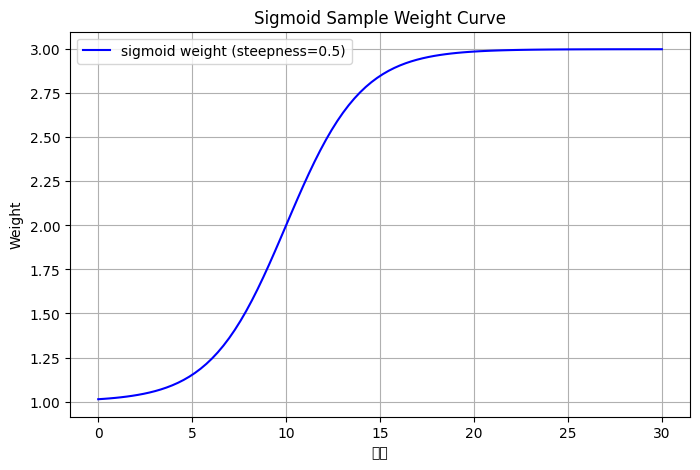

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit  # sigmoid

# 設定 sigmoid 參數
steepness = 0.5
ping = np.linspace(0, 30, 100)  # 坪數範圍 0~20

# 計算權重
weights = 1 + 2 * expit((ping - 10) * steepness)

# 畫圖
plt.figure(figsize=(8,5))
plt.plot(ping, weights, label=f"sigmoid weight (steepness={steepness})", color='blue')
plt.xlabel("坪數")
plt.ylabel("Weight")
plt.title("Sigmoid Sample Weight Curve")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# 用訓練資料做預測
y_train_pred = model.predict(X_train)

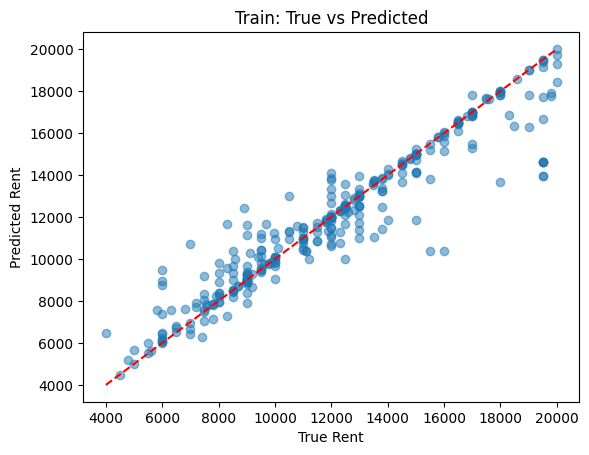

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_train, y_train_pred, alpha=0.5)
plt.xlabel("True Rent")
plt.ylabel("Predicted Rent")
plt.title("Train: True vs Predicted")
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()], 'r--')  # 45°線
plt.show()

In [ ]:
#print(X_train['ping'].to_string())

ping: 344.58 * 3
 拎包入住: 1001.99 * 1
可開伙: 1167.47 * 1
都近: 1422.36 * 1
只有近捷運: 144.06
只有近商圈: 792.03
都不近: 0.00
有電梯: 3198.39
隨時可遷入: 1021.62 * 1
可短租: 0.00
可養寵物: 615.09 * 1
整層住家: 1236.35
獨立套房: 1944.33
雅房: 0.00 * 1

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31199 (\N{CJK UNIFIED IDEOGRAPH-79DF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37329 (\N{CJK UNIFIED IDEOGRAPH-91D1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas

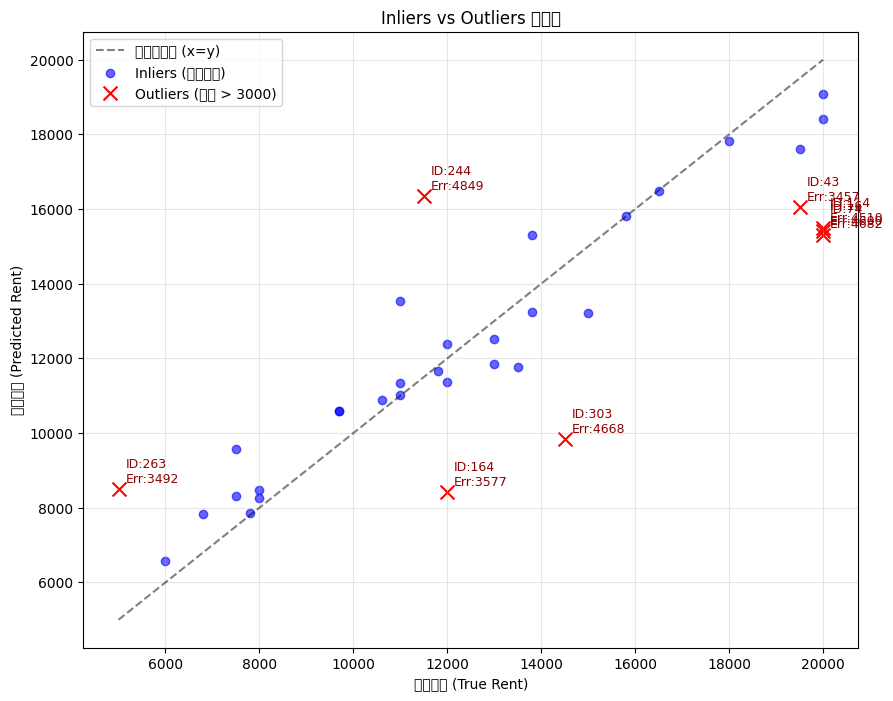

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


residuals = np.abs(y_test - y_pred)

threshold = 3000

outlier_mask = residuals > threshold
inlier_mask = residuals <= threshold

x_inliers = y_test[inlier_mask]
y_inliers = y_pred[inlier_mask]
x_outliers = y_test[outlier_mask]
y_outliers = y_pred[outlier_mask]

plt.figure(figsize=(10, 8))

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'k--', alpha=0.5, label='完美預測線 (x=y)')

plt.scatter(x_inliers, y_inliers, c='blue', alpha=0.6, label='Inliers (預測準確)')

plt.scatter(x_outliers, y_outliers, c='red', s=100, marker='x', label='Outliers (誤差 > 3000)')


for index, x_val, y_val in zip(x_outliers.index, x_outliers, y_outliers):
    label_text = f"ID:{index}\nErr:{int(abs(x_val-y_val))}"
    plt.annotate(label_text, (x_val, y_val),
                 xytext=(5, 5), textcoords='offset points', fontsize=9, color='darkred')

plt.xlabel('真實租金 (True Rent)')
plt.ylabel('預測租金 (Predicted Rent)')
plt.title('Inliers vs Outliers 分析圖')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
X_test[abs(y_pred - y_test) > 1000]

,拎包入住,AI影音,可短租,可開伙,可養寵物,押一付一,有陽台,有電梯,租金補貼,高齡友善,ping,cluster,type,可租補
225,1,0,0,0,0,0,0,0,0,0,9.0,8,3,0
43,0,0,0,1,0,0,0,0,0,0,10.0,5,3,0
263,0,0,0,1,0,0,0,0,0,0,4.0,8,1,0
303,0,0,0,1,1,0,1,0,0,0,7.0,18,2,0
57,1,0,0,0,0,0,0,0,0,0,22.0,10,4,0
16,0,0,0,1,0,0,0,0,0,0,25.0,13,4,0
164,0,0,0,0,0,0,0,0,1,0,5.0,1,2,0
356,1,0,0,1,1,0,0,0,0,0,16.0,5,4,0
236,1,0,0,0,0,0,0,0,0,0,7.0,11,4,0
244,1,0,0,0,0,0,1,0,1,0,7.0,10,2,1


In [ ]:
y_test[abs(y_pred - y_test) > 1000]

,Rent
225,13800
43,19500
263,5000
303,14500
57,8000
16,20000
164,12000
356,19500
236,13499
244,11500


In [ ]:
y_pred[abs(y_pred - y_test) > 1000]

array([13206.442 , 12688.91  , 11786.642 , 11083.19  ,  9437.256 ,
       10645.275 , 12876.53  ,  9992.807 , 11355.376 , 10300.109 ,
        9755.4795, 10422.878 , 11034.42  ,  9210.869 , 18069.285 ,
       17201.047 ,  7951.624 , 15969.929 ,  5649.0864, 17138.32  ,
       10601.206 , 15954.401 , 14599.296 ,  6409.7617, 12626.425 ],
      dtype=float32)

In [ ]:
import numpy as np

# 1. 找出 id=288 在 y_test 中的「位置」(Positional Index, 0, 1, 2...)
# 如果 288 不在 y_test (可能被分到 train 去了)，這行會報錯
pos_idx = np.where(y_test.index == 114)[0][0]

print(f"在 y_test 中的位置是第: {pos_idx} 列")

# 2. 驗證一下：取出該位置的值
print(f"該筆資料的真實租金 (y_test): {y_test.iloc[pos_idx]}")
print(f"該筆資料的預測租金 (y_pred): {y_pred[pos_idx]}")

在 y_test 中的位置是第: 34 列
該筆資料的真實租金 (y_test): 20000
該筆資料的預測租金 (y_pred): 14221.6806640625


In [ ]:
# print("權重:", model.coef_)
# print("截距:", model.intercept_)

# print("某筆 X_test:", X_test.iloc[pos_idx].values)

# manual_pred = (
#     X_test.iloc[pos_idx].values @ model.coef_
#     + model.intercept_
# )

# print("手算預測:", manual_pred)
# print("model 預測:", y_pred[pos_idx])

In [ ]:
y_pred

array([13206.442 , 15511.1455, 12688.91  , 11786.642 ,  6860.478 ,
       10233.549 , 11083.19  ,  9437.256 , 10645.275 , 12876.53  ,
        9992.807 , 11355.376 , 10300.109 ,  9755.4795, 10422.878 ,
       11034.42  , 11212.402 ,  9210.869 , 18069.285 , 17201.047 ,
       19705.639 ,  7951.624 , 10260.722 , 15969.929 ,  5649.0864,
       12961.358 , 17138.32  , 19076.69  , 10601.206 , 15954.401 ,
       11567.552 , 14599.296 ,  6409.7617, 11508.156 , 12626.425 ,
        8485.174 ], dtype=float32)

2x + 2 = 6

x = 3

6 - 8 = -2

x= 2.5

6 - 7 = -1

x = 2

6 - 6 = 0
AA-1 = I
[x1 ... xn][b1 ... bn] = [y1 .. yn] XB = Y => X = YB-1

[d1 ... dn]

[x1 + d1, x2 + d2, ... xn + dn]



In [ ]:
import numpy as np
print(np.eye(4)) # I , AI = A

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


prediction=base_score+∑tree_output

In [ ]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df)

    feature  importance
12     type    0.241071
10     ping    0.153443
11  cluster    0.134161
3       可開伙    0.097201
7       有電梯    0.091877
8      租金補貼    0.066271
0      拎包入住    0.049451
2       可短租    0.046833
6       有陽台    0.043275
4      可養寵物    0.031523
5      押一付一    0.018557
9      高齡友善    0.016640
1      AI影音    0.009696


# SHAP(加權分析)

In [ ]:
# #切割資料集
# from sklearn.model_selection import train_test_split
# x_feature_names = df_new.drop(['Rent'], axis=1).columns
# #print(x_feature_names)
# y_label_names = ['No', 'Yes']
# X = df_new.drop(['Rent'], axis=1)
# y = df_new['Rent']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# from sklearn.linear_model import LinearRegression
# import shap

# model = LinearRegression()

# model.fit(X_train, y_train)

In [ ]:
#載入 SHAP
import shap
shap.initjs()

/tmp/ipykernel_328/3646460138.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=np.array(feature_names)[sorted_idx])


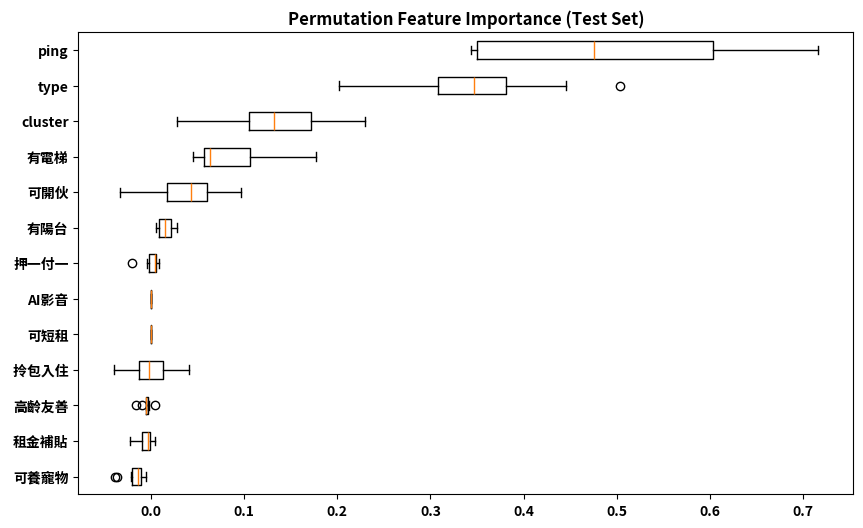

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=np.array(feature_names)[sorted_idx])
plt.title("Permutation Feature Importance (Test Set)")
plt.show()

In [ ]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

ping [4-20] 553

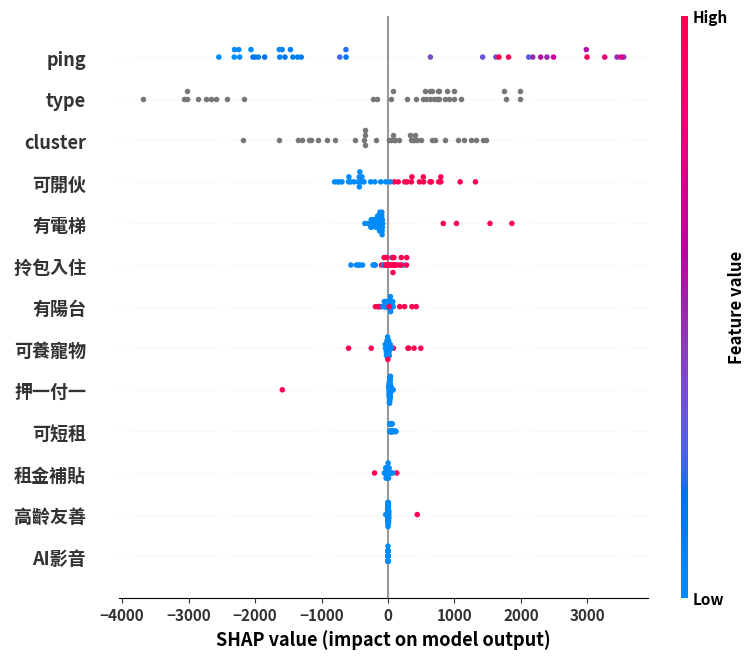

In [ ]:
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

In [ ]:
X_test.index.get_loc(114)

34

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25294 (\N{CJK UNIFIED IDEOGRAPH-62CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21253 (\N{CJK UNIFIED IDEOGRAPH-5305}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20303 (\N{CJK UNIFIED IDEOGRAPH-4F4F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  fig.canvas

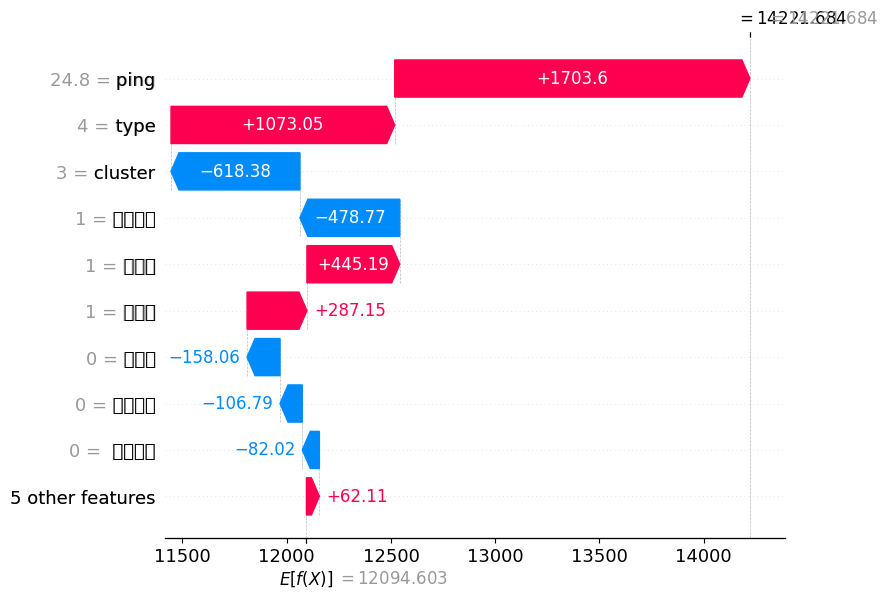

In [ ]:
index=34


shap.waterfall_plot(shap.Explanation(
    values=shap_values[index],
    base_values=explainer.expected_value,
    data=X_test.iloc[index],
    feature_names=feature_names
))